## Business Impact Analysis

This notebook evaluates the practical business impact of the churn prediction model by translating model outputs into cost-sensitive decisions. Rather than optimizing purely for predictive metrics, the analysis focuses on recall-driven targeting strategies and their implications for customer retention efforts.


In [1]:
import joblib
import json
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
model = joblib.load("data/telco-churn-model/final_logistic_model.pkl")

with open("data/final_threshold.json", "r") as f:
    threshold = json.load(f)["threshold"]


X_test  = np.load("data/X_test_processed.npy")
y_test  = np.load("data/y_test.npy")

threshold


0.35

## Business Cost Assumptions

To evaluate the practical impact of the churn prediction model, we define a simplified cost framework. The objective is to compare the cost of proactive retention efforts against the cost of losing a customer.

The following assumptions are used for illustration and can be adjusted based on business context:

- Cost of losing a churned customer: high (lost revenue and acquisition cost)
- Cost of offering a retention incentive: relatively low
- Retention offers are made to customers predicted as churners
- Company has no any other costs except Cost of Churn & Cost of Retention

These assumptions allow us to translate model predictions into monetary outcomes and evaluate decision thresholds from a business perspective.


In [3]:
# Business cost assumptions (example values)
COST_OF_CHURN = 500    # cost of losing a customer
COST_OF_RETENTION = 100  # cost of offering retention incentive

COST_OF_CHURN, COST_OF_RETENTION

(500, 100)

## Generating Model Predictions

The trained churn prediction model is applied to the test dataset to obtain churn probabilities. These probabilities are then converted into binary decisions using the previously selected decision threshold.


In [4]:
y_test_proba = model.predict_proba(X_test)[:, 1]

In [5]:
y_test_pred = (y_test_proba >= threshold).astype(int)

In [6]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
tn, fp, fn, tp

(np.int64(814), np.int64(221), np.int64(108), np.int64(266))

In [7]:
total_cost = (
    fn * COST_OF_CHURN +
    (tp + fp) * COST_OF_RETENTION
)

total_cost


np.int64(102700)

In [8]:
# If no model is used, all churners are lost
baseline_cost = y_test.sum() * COST_OF_CHURN
baseline_cost

np.int64(187000)

In [9]:
savings = baseline_cost - total_cost
savings


np.int64(84300)

## Cost-Based Evaluation Results

Applying the churn prediction model with a recall-focused decision threshold results in a substantial reduction in expected churn-related costs. Compared to a baseline scenario where no predictive action is taken, the model-driven retention strategy reduces total cost by approximately 45%.

This improvement is achieved by prioritizing the detection of churners and accepting a controlled increase in retention outreach. The results highlight the importance of cost-aware evaluation and demonstrate that meaningful business value can be obtained even when predictive performance gains are modest.


## Cost vs Threshold Analysis

Since real-world churn and retention costs are not known with certainty, this analysis evaluates model performance across multiple decision thresholds and cost assumptions. The objective is to identify robust operating regions where business savings remain high under different strategic scenarios.


In [10]:
import numpy as np

thresholds = np.arange(0.2, 0.61, 0.05)

COST_OF_RETENTION = 100
CHURN_COST_MULTIPLIERS = [5, 10, 20]  # churn cost = multiplier * retention cost


In [11]:
def compute_total_cost(y_true, y_proba, threshold, churn_cost, retention_cost):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total_cost = (
        fn * churn_cost +
        (tp + fp) * retention_cost
    )
    
    return total_cost

In [12]:
percent_conserved = {}

for multiplier in CHURN_COST_MULTIPLIERS:
    churn_cost = multiplier * COST_OF_RETENTION
    conserved = []
    
    baseline_cost = y_test.sum() * churn_cost
    
    for t in thresholds:
        model_cost = compute_total_cost(
            y_test,
            y_test_proba,
            t,
            churn_cost,
            COST_OF_RETENTION
        )
        
        pct = (baseline_cost - model_cost) / baseline_cost * 100
        conserved.append(pct)
    
    percent_conserved[f"ChurnCost_{multiplier}x"] = conserved


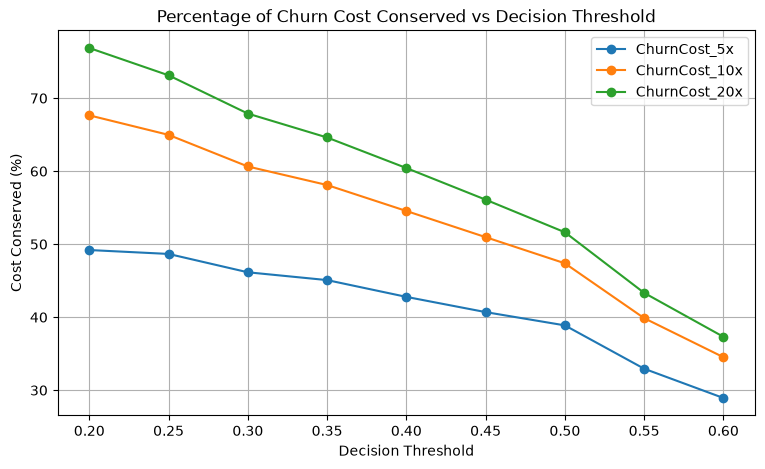

In [13]:
plt.figure(figsize=(9, 5))

for label, values in percent_conserved.items():
    plt.plot(thresholds, values, marker="o", label=label)

plt.xlabel("Decision Threshold")
plt.ylabel("Cost Conserved (%)")
plt.title("Percentage of Churn Cost Conserved vs Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()


## Interpretation: Percentage of Churn Cost Conserved

The percentage-based view highlights how effectively the churn prediction model reduces potential churn-related losses under different cost assumptions. Across all scenarios, lower decision thresholds consistently conserve a larger proportion of churn cost, emphasizing the importance of recall-focused strategies.

As the relative cost of churn increases, the benefits of aggressive churn detection become more pronounced. Importantly, the consistent shape of the curves across all cost scenarios demonstrates that the decision policy is robust to uncertainty in business cost estimates.

## Budget-Constrained Decision Optimization

The previous analysis evaluated decision thresholds assuming unlimited operational capacity. In practice, retention campaigns are constrained by fixed budgets and limited outreach capacity. This section incorporates budget constraints into the decision process to identify thresholds that maximize business value while remaining operationally feasible.


In [14]:
RETENTION_COST = 100
RETENTION_BUDGET = 100000

MAX_CUSTOMERS = RETENTION_BUDGET // RETENTION_COST
MAX_CUSTOMERS

1000

In [15]:
sorted_indices = np.argsort(y_test_proba)[::-1]

In [16]:
customer_counts = range(0, MAX_CUSTOMERS + 1, 10)
total_costs = []

for n in customer_counts:
    selected_indices = sorted_indices[:n]

    y_pred = np.zeros_like(y_test)
    y_pred[selected_indices] = 1

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = (
        fn * COST_OF_CHURN +
        (tp + fp) * COST_OF_RETENTION
    )

    total_costs.append(total_cost)


In [17]:
total_costs = np.array(total_costs)

best_idx = np.argmin(total_costs)
optimal_customers = list(customer_counts)[best_idx]
min_cost = total_costs[best_idx]

optimal_customers, min_cost


(730, np.int64(93000))

In [18]:
savings = baseline_cost - min_cost
savings


np.int64(655000)

In [19]:
if optimal_customers > 0:
    implied_threshold = y_test_proba[sorted_indices[optimal_customers - 1]]
else:
    implied_threshold = 1.0

implied_threshold


np.float64(0.1787870662928919)

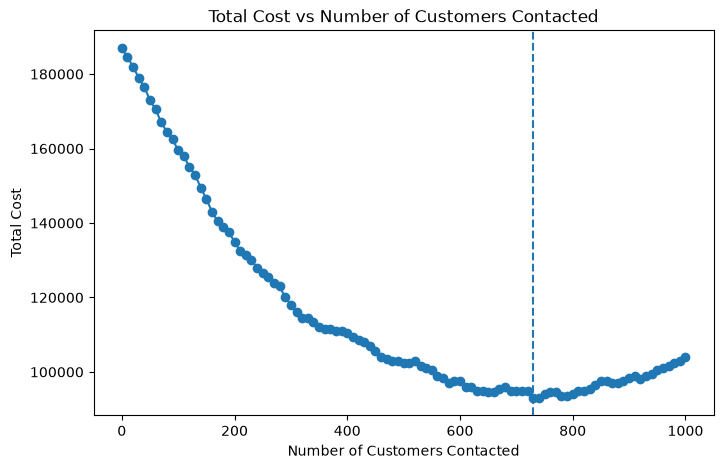

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(list(customer_counts), total_costs, marker='o')
plt.axvline(optimal_customers, linestyle='--')
plt.xlabel("Number of Customers Contacted")
plt.ylabel("Total Cost")
plt.title("Total Cost vs Number of Customers Contacted")
plt.show()

## Conclusion

- Customers were ranked by predicted churn probability and selected under a fixed retention budget.
- The optimal strategy is to contact the top-N highest-risk customers, minimizing total expected business cost.
- This results in maximum savings compared to taking no action by balancing retention costs and avoided churn losses.
- The implied probability cutoff is approximately **0.178**, derived from the top-N selection.
- Probability thresholds are not decision variables; customer ranking is the primary decision mechanism.
